# Stage 6: Doubly robust learning and observational policy evaluation

Train a three-fold cross-fitted DR-learner; compare S/T/DR treatment-effect and
policy performance; estimate policy profit from observational outcomes using
AIPW rather than oracle labels. Oracle quantities remain evaluation-only.

The 20,000-customer seed-42 cohort is split into **14,000 training**, **3,000
calibration**, and **3,000 final evaluation** customers. Calibration determines
policy thresholds; final evaluation outcomes never train a model or tune a
threshold. This final cohort is smaller than Stage 5's 6,000-customer holdout,
so Stage 5's reported totals should not be compared directly.

Method, assumptions, interval limitations, and reproducibility are documented in
[`docs/stage_6_doubly_robust.md`](../docs/stage_6_doubly_robust.md).

In [1]:
from pathlib import Path
import os
import sys

# Start Jupyter from the repository/notebooks directory, or explicitly set
# CAUSAL_INFERENCE_ROOT when the kernel starts elsewhere.
configured_root = os.environ.get("CAUSAL_INFERENCE_ROOT")
current_directory = Path.cwd().resolve()
candidates = (
    [Path(configured_root).expanduser().resolve()]
    if configured_root
    else [current_directory, *current_directory.parents]
)
PROJECT_ROOT = next(
    (
        candidate for candidate in candidates
        if all(
            (candidate / "src" / filename).is_file()
            for filename in ("causal_learners.py", "policies.py", "simulation.py")
        )
        and (candidate / "notebooks" / "04_doubly_robust_policy_evaluation.ipynb").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the Causal_Inference repository. Start Jupyter from "
        "the project or notebooks directory, or set CAUSAL_INFERENCE_ROOT "
        "to the repository path before running this notebook."
    )

SRC_DIRECTORY = PROJECT_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import brier_score_loss
from causal_learners import MODEL_FEATURES, SLearner, TLearner
from doubly_robust import DRLearner, doubly_robust_scores, evaluate_observational_policy
from policies import top_score_policy, random_policy, treat_none_policy, oracle_policy, evaluate_policy
from simulation import simulate_customers

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
SEED, VALUE, COST, CAPACITY = 42, 80.0, 10.0, 0.20
FIGURES = PROJECT_ROOT / "reports" / "figures"
TABLES = PROJECT_ROOT / "reports" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / name, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Project: {PROJECT_ROOT}")
print(f"Figures: {FIGURES}")
print(f"Tables: {TABLES}")

Project: C:\Samridh\Projects\Causal_Inference
Figures: C:\Samridh\Projects\Causal_Inference\reports\figures
Tables: C:\Samridh\Projects\Causal_Inference\reports\tables


## 1. Honest train, calibration, and final evaluation split

Only the training cohort contributes observed treatment and outcomes to fitting.
Calibration covariates determine economic score thresholds; its outcome column
is not used. All final evaluation results are computed after policies are fixed.

In [3]:
data = simulate_customers(number_of_customers=20_000, seed=SEED)
indices = np.random.default_rng(SEED).permutation(len(data))
training = data.iloc[indices[:14_000]].reset_index(drop=True)
calibration = data.iloc[indices[14_000:17_000]].reset_index(drop=True)
evaluation = data.iloc[indices[17_000:]].reset_index(drop=True)
cohorts = [training, calibration, evaluation]
for i, left in enumerate(cohorts):
    for right in cohorts[i+1:]:
        assert set(left.customer_id).isdisjoint(right.customer_id)
assert not set(MODEL_FEATURES) & {"customer_id", "treatment", "retained_90d", "true_cate", "true_mu0", "true_mu1", "true_propensity"}
print("Training / calibration / evaluation:", [len(frame) for frame in cohorts])

Training / calibration / evaluation: [14000, 3000, 3000]


## 2. Three-fold cross-fitted DR-learner and comparison models

For each training row, nuisance predictions come from models fitted without that
row. The raw pseudo-outcome is

`mu1 - mu0 + T*(Y-mu1)/e - (1-T)*(Y-mu0)/(1-e)`.

Only propensity denominators are clipped (0.05–0.95); pseudo-outcomes are not.
A final regression learns CATE from these scores. DR nuisance probability models
use no class balancing, because probability calibration matters. Stage 5's S/T
configurations are retained. Thus this comparison includes model-configuration
differences and does not isolate the estimator alone.

In [4]:
models = {"S-learner": SLearner(SEED), "T-learner": TLearner(SEED),
          "DR-learner": DRLearner(random_seed=SEED, n_splits=3)}
observed_training = training[MODEL_FEATURES + ["treatment", "retained_90d"]]
for name, model in models.items():
    model.fit(observed_training)
    print(name, "fitted")
dr = models["DR-learner"]
for fit_indices, heldout_indices in dr.fold_indices_:
    assert set(fit_indices).isdisjoint(heldout_indices)
assert (dr.fold_assignments_ >= 0).all()
nuisance = dr.predict_nuisance(evaluation[MODEL_FEATURES])
y = evaluation.retained_90d.to_numpy()
t = evaluation.treatment.to_numpy()
score0, score1, effect_score = doubly_robust_scores(
    y, t, nuisance.mu0, nuisance.mu1, nuisance.propensity)
oof = dr.oof_nuisance_
diagnostics = pd.DataFrame([
    {"cohort": "training (out of fold)", "customers": len(training),
     "propensity_brier": brier_score_loss(training.treatment, oof.propensity),
     "min_propensity": oof.propensity.min(), "max_propensity": oof.propensity.max(),
     "clipped_fraction": ((oof.propensity < 0.05) | (oof.propensity > 0.95)).mean(),
     "mean_raw_aipw_effect": dr.pseudo_outcome_.mean()},
    {"cohort": "final evaluation", "customers": len(evaluation),
     "propensity_brier": brier_score_loss(t, nuisance.propensity),
     "min_propensity": nuisance.propensity.min(), "max_propensity": nuisance.propensity.max(),
     "clipped_fraction": ((nuisance.propensity < 0.05) | (nuisance.propensity > 0.95)).mean(),
     "mean_raw_aipw_effect": effect_score.mean()},
])
diagnostics.to_csv(TABLES / "stage6_nuisance_diagnostics.csv", index=False)
display(diagnostics)

S-learner fitted


T-learner fitted


DR-learner fitted


,cohort,customers,propensity_brier,min_propensity,max_propensity,clipped_fraction,mean_raw_aipw_effect
0,training (out of fold),14000,0.195841,0.017896,0.865870,0.003000,0.147977
1,final evaluation,3000,0.190311,0.043409,0.840356,0.000667,0.141547


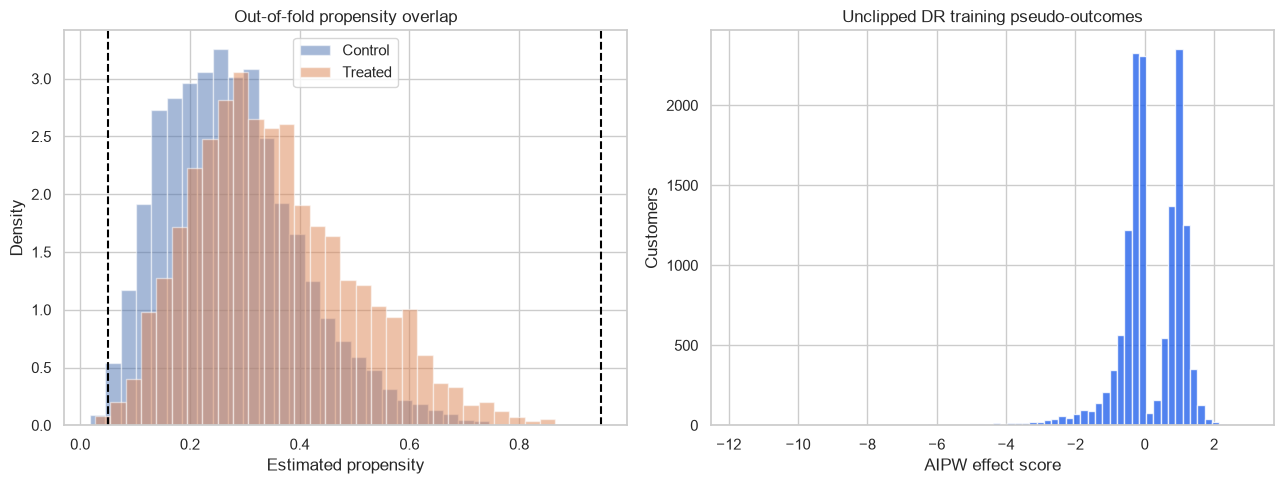

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for arm, label in [(0, "Control"), (1, "Treated")]:
    axes[0].hist(oof.loc[training.treatment == arm, "propensity"], bins=30,
                 alpha=0.5, density=True, label=label)
axes[0].axvline(0.05, color="black", linestyle="--")
axes[0].axvline(0.95, color="black", linestyle="--")
axes[0].set(title="Out-of-fold propensity overlap", xlabel="Estimated propensity", ylabel="Density")
axes[0].legend()
axes[1].hist(dr.pseudo_outcome_, bins=70, color="#2563EB", alpha=0.8)
axes[1].set(title="Unclipped DR training pseudo-outcomes", xlabel="AIPW effect score", ylabel="Customers")
save_figure(fig, "stage6_nuisance_diagnostics.png")

## 3. Held-out CATE estimation

The following metrics use simulator truth only for final evaluation. Calibration
compares mean predicted and true effects within predicted-effect deciles.

,model,true_ate,predicted_ate,ate_error,pehe,cate_mae,cate_correlation
2,DR-learner,0.15372,0.147106,0.006614,0.080985,0.062946,0.716014
0,S-learner,0.15372,0.090200,0.063520,0.091197,0.069541,0.785129
1,T-learner,0.15372,0.092286,0.061434,0.097259,0.076002,0.683721


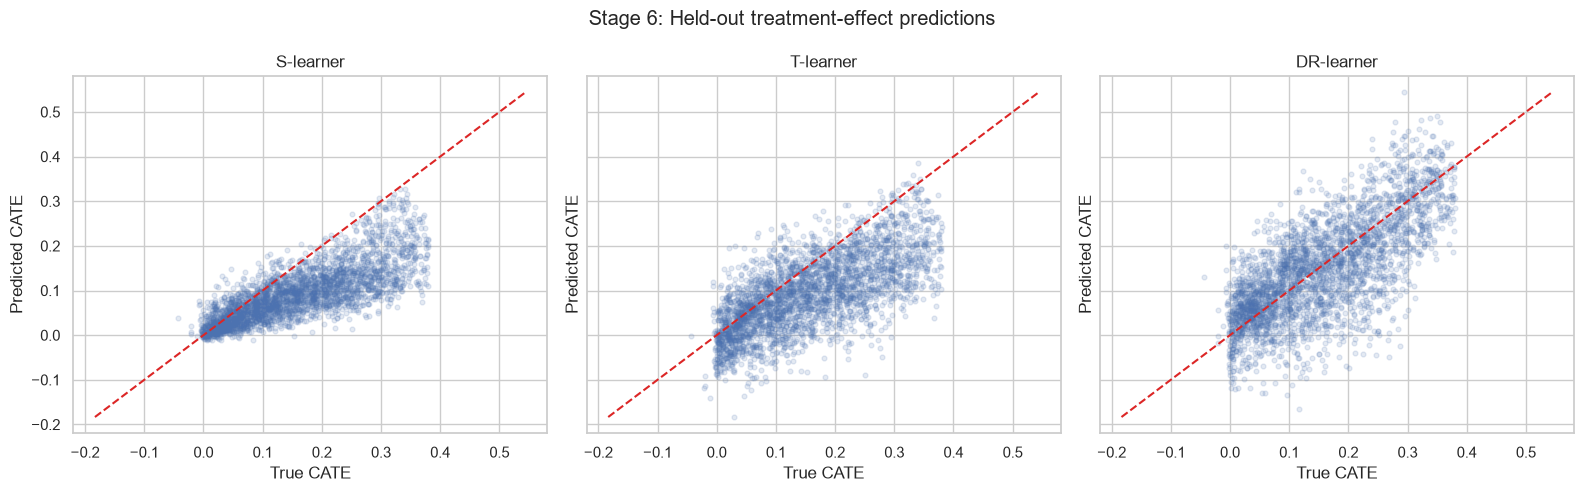

In [6]:
predictions = {name: model.predict_cate(evaluation[MODEL_FEATURES]) for name, model in models.items()}
truth = evaluation.true_cate.to_numpy()
metrics = pd.DataFrame([
    {"model": name, "true_ate": truth.mean(), "predicted_ate": pred.mean(),
     "ate_error": abs(pred.mean()-truth.mean()),
     "pehe": np.sqrt(np.mean((pred-truth)**2)),
     "cate_mae": np.abs(pred-truth).mean(),
     "cate_correlation": np.corrcoef(pred, truth)[0, 1]}
    for name, pred in predictions.items()
]).sort_values("pehe")
metrics.to_csv(TABLES / "stage6_cate_metrics.csv", index=False)
display(metrics)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for axis, (name, pred) in zip(axes, predictions.items()):
    axis.scatter(truth, pred, s=12, alpha=0.15)
    limits = [min(truth.min(), min(v.min() for v in predictions.values())),
              max(truth.max(), max(v.max() for v in predictions.values()))]
    axis.plot(limits, limits, color="#DC2626", linestyle="--")
    axis.set(title=name, xlabel="True CATE", ylabel="Predicted CATE")
fig.suptitle("Stage 6: Held-out treatment-effect predictions")
save_figure(fig, "stage6_cate_comparison.png")

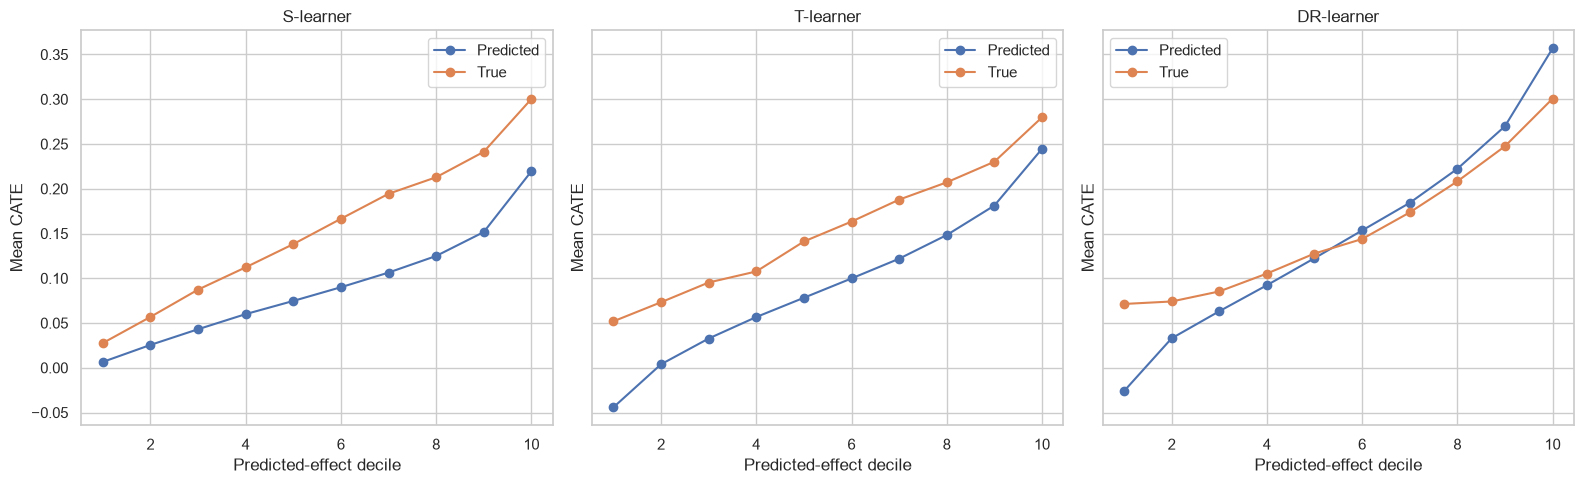

In [7]:
calibration_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for axis, (name, pred) in zip(axes, predictions.items()):
    frame = pd.DataFrame({"predicted": pred, "true": truth})
    frame["group"] = pd.qcut(frame.predicted, 10, duplicates="drop")
    grouped = frame.groupby("group", observed=True).agg(
        predicted=("predicted", "mean"), true=("true", "mean"), customers=("true", "size"))
    grouped["rank"] = np.arange(1, len(grouped)+1)
    grouped["model"] = name
    calibration_rows.append(grouped.reset_index(drop=True))
    axis.plot(grouped["rank"], grouped.predicted, marker="o", label="Predicted")
    axis.plot(grouped["rank"], grouped.true, marker="o", label="True")
    axis.set(title=name, xlabel="Predicted-effect decile", ylabel="Mean CATE")
    axis.legend()
pd.concat(calibration_rows).to_csv(TABLES / "stage6_cate_calibration.csv", index=False)
save_figure(fig, "stage6_cate_calibration.png")

## 4. Calibrate economic thresholds, then enforce deployment capacity

Thresholds are the lowest positive scores among the top 20% of calibration
customers. At evaluation time, only customers meeting that prechosen threshold
are eligible. If too many qualify, take the highest scores up to the 20% cap.
This last cap uses evaluation covariates, never treatment or outcomes. Record
how many customers qualified before the cap so that cohort dependence is visible.

AIPW evaluates **incremental** profit relative to treating nobody. Use the paired
per-customer contributions `decision * (80 * AIPW_effect - 10)`; subtracting two
independent value intervals would ignore their covariance. All policies share
the same nuisance estimates fitted on the training cohort.

In [8]:
decisions = {"Treat nobody": treat_none_policy(len(evaluation)),
             "Random 20%": random_policy(len(evaluation), capacity=CAPACITY, seed=SEED)}
threshold_rows = []
for name, model in models.items():
    calibration_scores = VALUE * model.predict_cate(calibration[MODEL_FEATURES]) - COST
    selected = top_score_policy(calibration_scores, capacity=CAPACITY, require_positive=True).astype(bool)
    threshold = float(calibration_scores[selected].min()) if selected.any() else np.inf
    scores = VALUE * predictions[name] - COST
    qualifies = (scores > 0) & (scores >= threshold)
    eligible_scores = np.where(qualifies, scores, 0.0)
    decisions[name] = top_score_policy(eligible_scores, capacity=CAPACITY, require_positive=True)
    threshold_rows.append({"model": name, "incremental_value_threshold": threshold,
                           "calibration_treated": int(selected.sum()),
                           "evaluation_qualified_before_cap": int(qualifies.sum()),
                           "evaluation_treated": int(decisions[name].sum()),
                           "capacity_cap_active": bool(qualifies.sum() > int(CAPACITY*len(evaluation)))})
thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(TABLES / "stage6_policy_thresholds.csv", index=False)
display(thresholds)

observational_rows, truth_rows = [], []
for name, decision in decisions.items():
    observational_rows.append(evaluate_observational_policy(
        y, t, decision, nuisance.mu0, nuisance.mu1, nuisance.propensity, policy_name=name))
    truth_rows.append(evaluate_policy(evaluation, decision, name, capacity=CAPACITY))
# The oracle is an upper bound evaluated with simulator truth, not a deployable policy.
oracle_decision = oracle_policy(evaluation, capacity=CAPACITY)
truth_rows.append(evaluate_policy(evaluation, oracle_decision, "Oracle 20%", capacity=CAPACITY))
observational = pd.DataFrame(observational_rows)
truth_policies = pd.DataFrame(truth_rows)
oracle_profit = truth_policies.loc[truth_policies.policy == "Oracle 20%", "incremental_profit"].iloc[0]
truth_policies["regret_vs_oracle"] = oracle_profit - truth_policies.incremental_profit
truth_policies["oracle_profit_captured"] = truth_policies.incremental_profit / oracle_profit
comparison = observational.merge(truth_policies[["policy", "incremental_profit", "regret_vs_oracle", "oracle_profit_captured"]], on="policy")
comparison["estimation_error"] = comparison.dr_incremental_profit - comparison.incremental_profit
comparison.to_csv(TABLES / "stage6_observational_policy_results.csv", index=False)
truth_policies.to_csv(TABLES / "stage6_oracle_policy_results.csv", index=False)
display(comparison[["policy", "treated_count", "dr_incremental_profit", "ci_lower_profit", "ci_upper_profit", "incremental_profit", "estimation_error"]])
display(truth_policies[["policy", "treated_count", "incremental_profit", "regret_vs_oracle", "oracle_profit_captured"]])

,model,incremental_value_threshold,calibration_treated,evaluation_qualified_before_cap,evaluation_treated,capacity_cap_active
0,S-learner,1.128787,600,563,563,False
1,T-learner,3.291088,600,568,568,False
2,DR-learner,9.685156,600,579,579,False


,policy,treated_count,dr_incremental_profit,ci_lower_profit,ci_upper_profit,incremental_profit,estimation_error
0,Treat nobody,0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Random 20%,600,-1264.754322,-5149.180907,2619.672262,1446.319475,-2711.073798
2,S-learner,563,4552.402612,915.912234,8188.892990,6646.581495,-2094.178883
3,T-learner,568,4414.139027,710.656350,8117.621704,5987.926230,-1573.787203
4,DR-learner,579,4998.545263,1265.190121,8731.900406,6994.430222,-1995.884959


,policy,treated_count,incremental_profit,regret_vs_oracle,oracle_profit_captured
0,Treat nobody,0,0.000000,8715.271991,0.000000
1,Random 20%,600,1446.319475,7268.952516,0.165952
2,S-learner,563,6646.581495,2068.690497,0.762636
3,T-learner,568,5987.926230,2727.345762,0.687061
4,DR-learner,579,6994.430222,1720.841769,0.802549
5,Oracle 20%,600,8715.271991,0.000000,1.000000


### Interval interpretation

Error bars below are pointwise, approximate normal intervals based on empirical
paired-score variance. For a fixed rule, valid asymptotic inference also needs
independent observations, overlap, and sufficiently accurate nuisance models.
The strict cohort-level cap adds dependence between decisions; these bars do
**not** provide certified coverage for that allocation rule. They omit nuisance
and calibration fitting variability and are not simultaneous intervals or a
model-selection guarantee. Cross-fitting does not fix unobserved confounding.
Profit uncertainty can be large even when oracle PEHE appears modest.

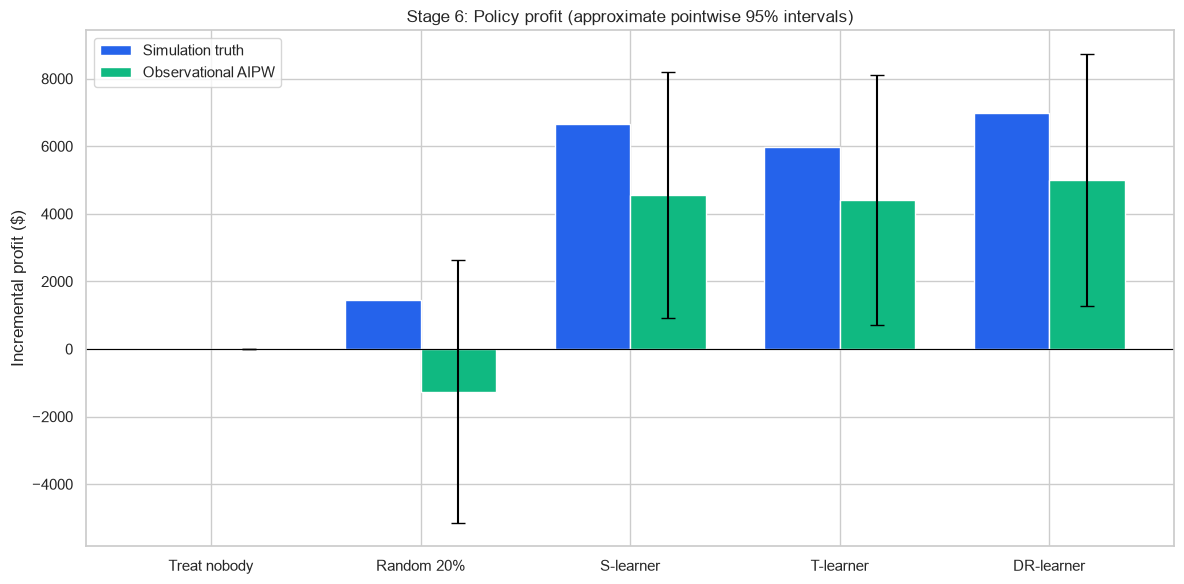

In [9]:
fig, axis = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
axis.bar(x-0.18, comparison.incremental_profit, width=0.36, label="Simulation truth", color="#2563EB")
axis.bar(x+0.18, comparison.dr_incremental_profit, width=0.36, label="Observational AIPW", color="#10B981")
axis.errorbar(x+0.18, comparison.dr_incremental_profit,
              yerr=np.vstack([comparison.dr_incremental_profit-comparison.ci_lower_profit,
                              comparison.ci_upper_profit-comparison.dr_incremental_profit]),
              fmt="none", capsize=5, color="black")
axis.set_xticks(x, comparison.policy)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Stage 6: Policy profit (approximate pointwise 95% intervals)", ylabel="Incremental profit ($)")
axis.legend()
save_figure(fig, "stage6_observational_policy_profit.png")

## 5. Evaluation sensitivity to propensity clipping

Hold all fitted models and policy decisions fixed and vary only evaluation
propensity clipping. This isolates evaluation-weight sensitivity; it is not a
retraining study and does not select a preferred clipping level from test data.
Clipping reduces extreme weights but may introduce bias.

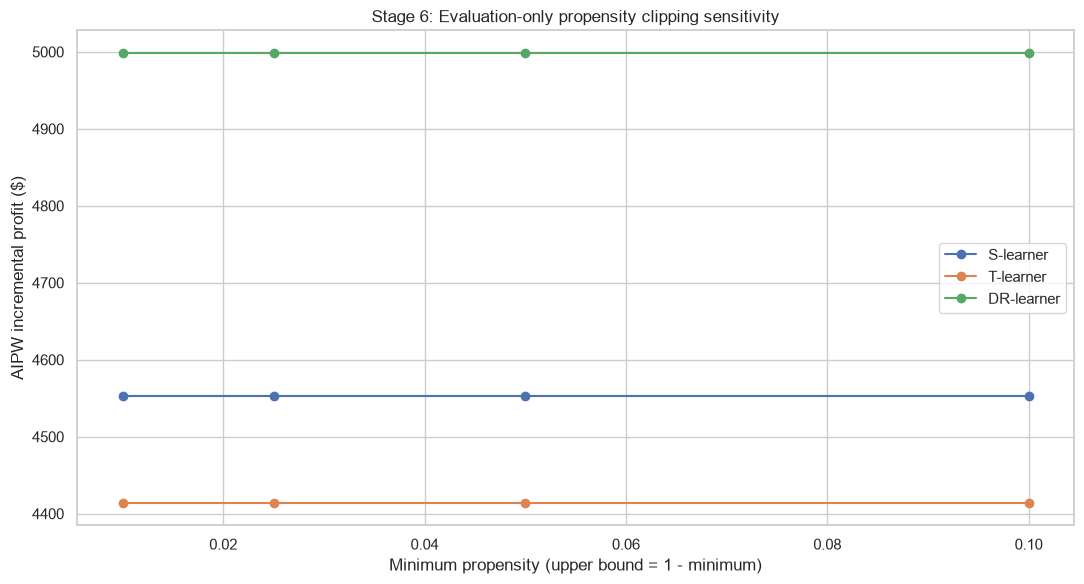

,policy,propensity_clip,dr_incremental_profit,propensity_clipped_fraction,maximum_observed_inverse_weight,observed_weight_ess
0,S-learner,0.010,4552.402612,0.000000,14.453324,2067.422241
1,T-learner,0.010,4414.139027,0.000000,14.453324,2067.422241
2,DR-learner,0.010,4998.545263,0.000000,14.453324,2067.422241
3,S-learner,0.025,4552.402612,0.000000,14.453324,2067.422241
4,T-learner,0.025,4414.139027,0.000000,14.453324,2067.422241
5,DR-learner,0.025,4998.545263,0.000000,14.453324,2067.422241
6,S-learner,0.050,4552.402612,0.000667,14.453324,2067.426014
7,T-learner,0.050,4414.139027,0.000667,14.453324,2067.426014
8,DR-learner,0.050,4998.545263,0.000667,14.453324,2067.426014
9,S-learner,0.100,4552.402612,0.030000,10.000000,2104.191860


In [10]:
sensitivity_rows = []
for clip in [0.01, 0.025, 0.05, 0.10]:
    for name in models:
        row = evaluate_observational_policy(y, t, decisions[name], nuisance.mu0, nuisance.mu1,
                                             nuisance.propensity, policy_name=name, propensity_clip=clip)
        row["propensity_clip"] = clip
        sensitivity_rows.append(row)
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(TABLES / "stage6_clipping_sensitivity.csv", index=False)
fig, axis = plt.subplots(figsize=(11, 6))
for name, frame in sensitivity.groupby("policy", sort=False):
    axis.plot(frame.propensity_clip, frame.dr_incremental_profit, marker="o", label=name)
axis.set(title="Stage 6: Evaluation-only propensity clipping sensitivity",
         xlabel="Minimum propensity (upper bound = 1 - minimum)", ylabel="AIPW incremental profit ($)")
axis.legend()
save_figure(fig, "stage6_clipping_sensitivity.png")
display(sensitivity[["policy", "propensity_clip", "dr_incremental_profit", "propensity_clipped_fraction", "maximum_observed_inverse_weight", "observed_weight_ess"]])

## Results from the saved seed-42 run

DR has PEHE **0.0810** and absolute ATE error **0.0066**, versus S-learner PEHE
0.0912 and T-learner PEHE 0.0973. DR targets 579 of 3,000 evaluation customers,
with simulation-truth incremental profit **$6,994.43** (80.3% of oracle profit).
Its observational AIPW estimate is **$4,998.55**, with an approximate pointwise
95% interval **[$1,265.19, $8,731.90]**. These intervals overlap across the learned
policies and do not establish a statistical ranking.

All learned thresholds select fewer than 20% on this holdout, so the strict
capacity cap is inactive here. Evaluation-only clipping changes none of the
learned-policy point estimates over the tested range; affected propensities are
outside their treated subsets. Neither finding establishes robustness across
other seeds or populations. Refer to the saved CSV tables for unrounded results.


## 6. Stage completion checks and interpretation

No assertion requires DR to beat S/T. Estimation and policy performance are
empirical questions. Compare effect error, oracle policy regret, observational
estimation error, overlap diagnostics, and interval width together. Single-seed
results are illustrative; repeated-seed robustness and hidden-confounding stress
tests remain future work.

In [11]:
expected_figures = ["stage6_nuisance_diagnostics.png", "stage6_cate_comparison.png",
                    "stage6_cate_calibration.png", "stage6_observational_policy_profit.png",
                    "stage6_clipping_sensitivity.png"]
expected_tables = ["stage6_nuisance_diagnostics.csv", "stage6_cate_metrics.csv",
                   "stage6_cate_calibration.csv", "stage6_policy_thresholds.csv",
                   "stage6_observational_policy_results.csv", "stage6_oracle_policy_results.csv",
                   "stage6_clipping_sensitivity.csv"]
checks = {
    "disjoint cohorts": all(set(cohorts[i].customer_id).isdisjoint(cohorts[j].customer_id)
                            for i in range(3) for j in range(i+1, 3)),
    "oracle columns excluded": not set(MODEL_FEATURES) & {"true_cate", "true_mu0", "true_mu1", "true_propensity"},
    "out-of-fold coverage": (dr.fold_assignments_ >= 0).all(),
    "finite bounded CATE predictions": all(np.isfinite(p).all() and (np.abs(p) <= 1).all() for p in predictions.values()),
    "policies respect capacity": all(d.sum() <= int(CAPACITY*len(evaluation)) for d in decisions.values()),
    "oracle dominates learned policies": (truth_policies.regret_vs_oracle >= -1e-8).all(),
    "finite observational estimates": np.isfinite(comparison.select_dtypes(include="number")).all().all(),
    "zero incremental treat-none estimate": observational.loc[observational.policy == "Treat nobody", "dr_incremental_profit"].iloc[0] == 0,
    "five figure files saved": all((FIGURES / name).is_file() and (FIGURES / name).stat().st_size > 0 for name in expected_figures),
    "seven result tables saved": all((TABLES / name).is_file() for name in expected_tables),
}
display(pd.DataFrame({"check": checks.keys(), "passed": checks.values()}))
assert all(checks.values())
print("Stage 6 doubly robust learning and policy evaluation checks passed.")

,check,passed
0,disjoint cohorts,True
1,oracle columns excluded,True
2,out-of-fold coverage,True
3,finite bounded CATE predictions,True
4,policies respect capacity,True
5,oracle dominates learned policies,True
6,finite observational estimates,True
7,zero incremental treat-none estimate,True
8,five figure files saved,True
9,seven result tables saved,True


Stage 6 doubly robust learning and policy evaluation checks passed.
